<a href="https://colab.research.google.com/github/YamenObeidat/Activity-3--DBSCAN-PCA/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
print("Dataset Head:\n", df.head())

Dataset Head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
df = df.dropna()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [8]:
var_ratios = pca.explained_variance_ratio_
total_var = sum(var_ratios)

In [9]:
print(f"Variance in Component 1: {var_ratios[0]:.2%}")
print(f"Variance in Component 2: {var_ratios[1]:.2%}")
print(f"Total variance retained by 2 components: {total_var:.2%}")

Variance in Component 1: 72.96%
Variance in Component 2: 22.85%
Total variance retained by 2 components: 95.81%


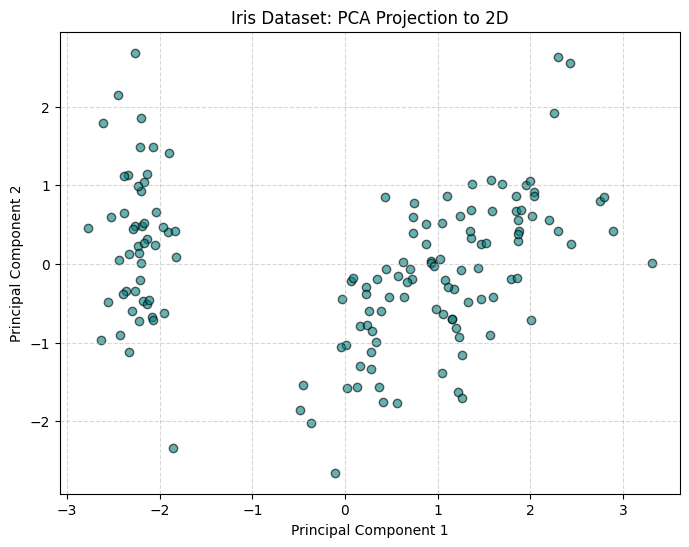

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='teal', edgecolors='k', alpha=0.6)
plt.title("Iris Dataset: PCA Projection to 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [11]:
dbscan_orig = DBSCAN(eps=0.5, min_samples=5)
labels_orig = dbscan_orig.fit_predict(X_scaled)

In [12]:
dbscan_pca = DBSCAN(eps=0.5, min_samples=5)
labels_pca = dbscan_pca.fit_predict(X_pca)

In [13]:
print("DBSCAN Tuning Results")
print("-" * 30)
print(f"Original Data - Clusters: {len(set(labels_orig)) - (1 if -1 in labels_orig else 0)}")
print(f"Original Data - Noise Points: {list(labels_orig).count(-1)}")
print(f"PCA Data      - Clusters: {len(set(labels_pca)) - (1 if -1 in labels_pca else 0)}")
print(f"PCA Data      - Noise Points: {list(labels_pca).count(-1)}")

DBSCAN Tuning Results
------------------------------
Original Data - Clusters: 2
Original Data - Noise Points: 34
PCA Data      - Clusters: 2
PCA Data      - Noise Points: 12


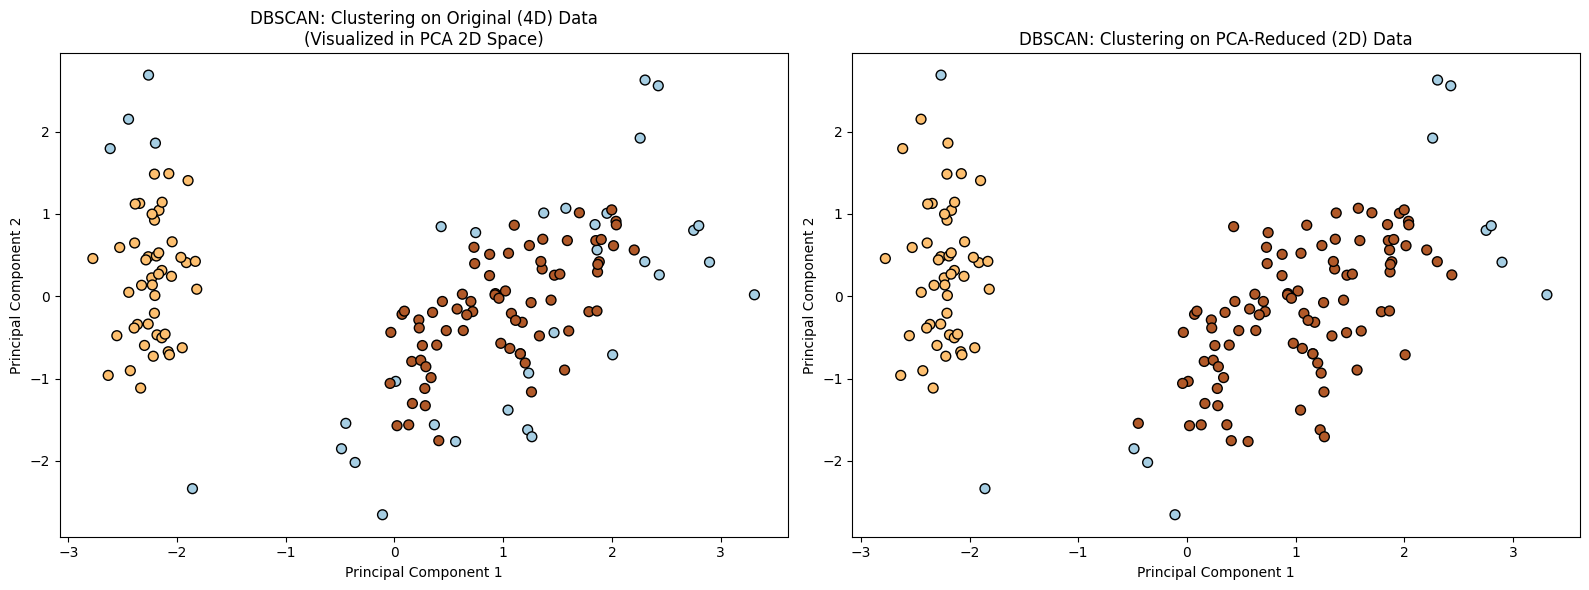

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_orig, cmap='Paired', edgecolors='k', s=50)
ax1.set_title("DBSCAN: Clustering on Original (4D) Data\n(Visualized in PCA 2D Space)")
ax1.set_xlabel("Principal Component 1")
ax1.set_ylabel("Principal Component 2")
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='Paired', edgecolors='k', s=50)
ax2.set_title("DBSCAN: Clustering on PCA-Reduced (2D) Data")
ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [19]:
n_clusters_orig = len(set(labels_orig)) - (1 if -1 in labels_orig else 0)
n_noise_orig = list(labels_orig).count(-1)

n_clusters_pca = len(set(labels_pca)) - (1 if -1 in labels_pca else 0)
n_noise_pca = list(labels_pca).count(-1)

results_comparison = pd.DataFrame({
    "Metric": ["Epsilon (eps)", "Min Samples", "Total Clusters", "Noise Points"],
    "Without PCA (Original)": [0.5, 5, n_clusters_orig, n_noise_orig],
    "With PCA (2D)": [0.5, 5, n_clusters_pca, n_noise_pca]
})

print(results_comparison.to_string(index=False))

        Metric  Without PCA (Original)  With PCA (2D)
 Epsilon (eps)                     0.5            0.5
   Min Samples                     5.0            5.0
Total Clusters                     2.0            2.0
  Noise Points                    34.0           12.0
